In [73]:
import numpy as np
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [ ]:
# Read the data files
tab3 = Table.read('apjabbb34t3_mrt.txt', format='ascii') # QSO data
tab4 = Table.read('apjabbb34t4_mrt.txt', format='ascii') # VP component data

Text(0.5, 0, '$N_{aod}$')

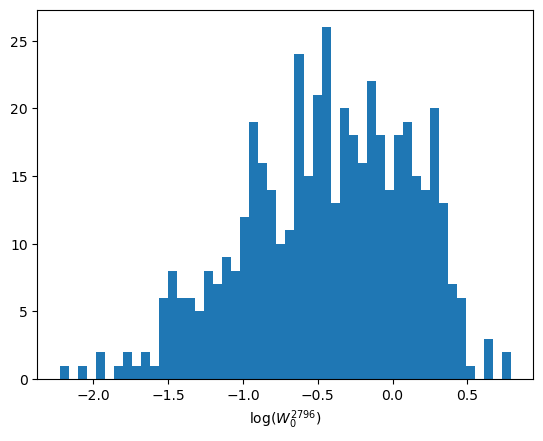

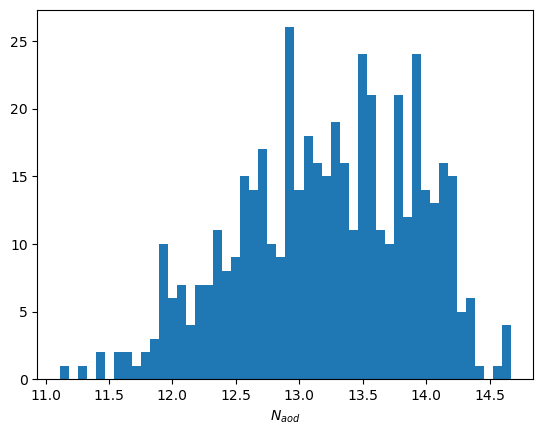

In [ ]:
# REW and AOD column density distributions
W2796 = tab3['W2796'] # REW of the 2796 line
N_aod = tab3['Naod'] # aparent optical depth column density
plt.figure(1)
REW_dist = plt.hist(np.log10(W2796), bins=50)
plt.xlabel('$\log(W_{0}^{2796})$')
plt.figure(2)    
N_dist =plt.hist(N_aod, bins=50)
plt.xlabel('$N_{aod}$')

Text(0.5, 0, 'VP Components')

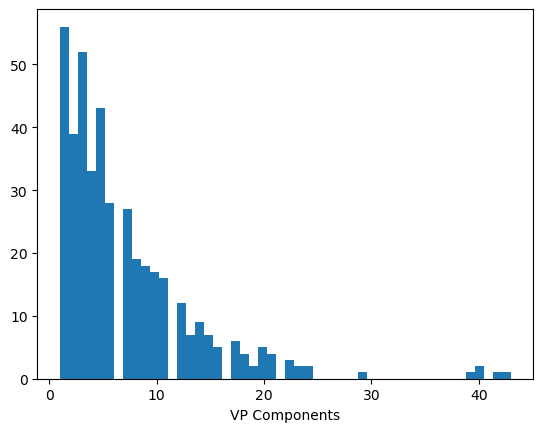

In [ ]:
# Distrubution of the max number of VP components per absorber

total_components = dict()
vp_component = tab4["Ncld"] # vp component index
z_abs = tab4["zabs"] # absorber redshift
tab4_qsos = tab4["QSO"] # QSO identifier

# finds highest VP component for each absorber
# Writes a dictionary with keys (QSO identifier, z_abs) and values as the highest VP component
for i in range(1,len(vp_component)-1): 
    if vp_component[i+1] <= vp_component[i]:
        total_components[(tab4_qsos[i], z_abs[i])] = vp_component[i]
total_components[(tab4_qsos[len(vp_component)-1], z_abs[len(vp_component)-1])] = vp_component[len(vp_component)-1]

plt.figure(3)
plt.hist(total_components.values(), bins=50)
plt.xlabel("VP Components")

In [123]:
# Match the absorber's VP components with the absorber's corresponding REW value

z_abs_t3 = tab3["zabs"] # absorber redshift from table 3
qso_tab3 = tab3["QSO"] # QSO identifier from table 3
z_match = [];
W_match = [];
vp_comp_match = [];

# Matches the REW for each absorber in the vp dictionary
for i in range(len(tab3["QSO"])):
    if total_components.get((qso_tab3[i], z_abs_t3[i]), 0) > 0: # ensures that the absorber is in the dictionary
        vp_comp_match.append(total_components.get((qso_tab3[i], z_abs_t3[i]), 0))
        W_match.append(W2796[i])
        z_match.append(z_abs_t3[i])


# fitting an exponential model to the data

def model(x, A, B):
    return 1+ A * np.exp(B * x)

sort_ind = np.argsort(W_match)
x = np.asarray(W_match)[sort_ind]
y = np.asarray(vp_comp_match)[sort_ind]

p0 = [np.max(y), 1.0]

popt, pcov = curve_fit(model, np.log10(x), y, p0=p0)

x_arr = np.asarray(np.linspace(-2.5, 1, 1000))
A, B = popt
y_fit = model(x_arr, A, B)
# perr = np.sqrt(np.diag(pcov))
# y_fit_plus = model(x_arr, A,B + perr[1])
# y_fit_minus = model(x_arr, A,B - perr[1])
print(popt)

[9.08404981 1.91456897]


Text(0, 0.5, 'VP Components')

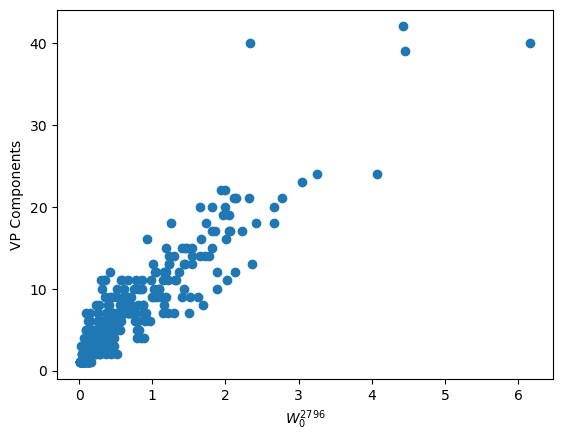

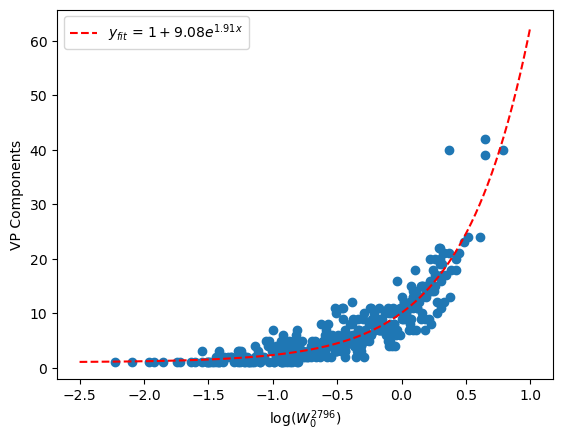

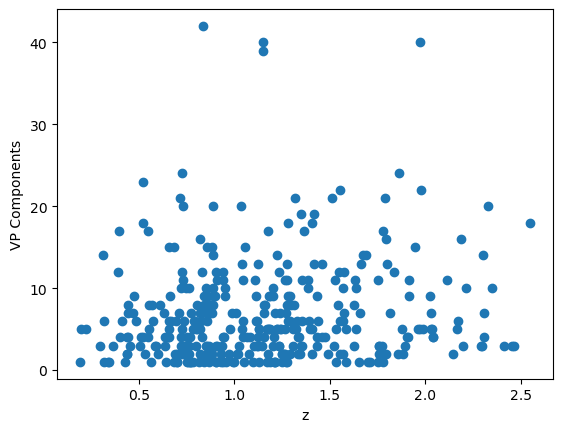

In [124]:
plt.figure(4)
plt.scatter(W_match, vp_comp_match)
plt.xlabel('$W_{0}^{2796}$')
plt.ylabel('VP Components')

plt.figure(5)
plt.scatter(np.log10(W_match), vp_comp_match)
plt.plot(x_arr, y_fit, color='red', linestyle='--', label='$y_{fit}$ = $1 +  9.08 e^{1.91 x}$')
# plt.plot(x_arr, y_fit_plus, color='red', linestyle=':')
# plt.plot(x_arr, y_fit_minus, color='red', linestyle=':')   
# plt.xlim(-2,1)
# plt.ylim(0,5)
plt.xlabel('$\log(W_{0}^{2796})$')
plt.ylabel('VP Components')
plt.legend()

plt.figure(6)
plt.scatter(z_match, vp_comp_match)
plt.xlabel('z')
plt.ylabel('VP Components')


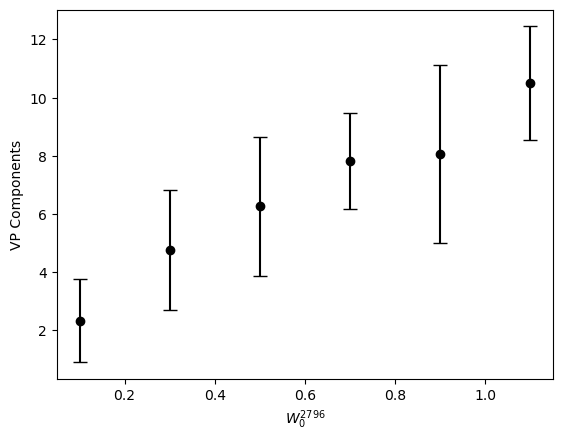

In [ ]:
# Plot the distribution of VP components in different REW bins
bins = [0,0.2,0.4,0.6,0.8,1.0,1.2]

plt.figure(7)
for j in range(len(bins)-1):
    vp_in_bin = [];
    for i in range(len(W_match)): # checks if each element fits into the current bin
        if bins[j] <= W_match[i] < bins[j+1]:
            vp_in_bin.append(vp_comp_match[i])
    plt.errorbar(bins[j]+0.1, np.mean(vp_in_bin), np.std(vp_in_bin), fmt='ko',  capsize=5)
plt.xlabel('$W_{0}^{2796}$')
plt.ylabel('VP Components')
plt.show()
